In [ ]:
!pip install --upgrade xee

In [ ]:
!pip install -U geemap

In [64]:
import ee

In [66]:
ee.Authenticate()
ee.Initialize(project = "ee-grmntfrancis0",
              opt_url = 'https://earthengine-highvolume.googleapis.com')

In [67]:
import geemap

In [68]:
map = geemap.Map()
map

Map(center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', transp…

In [69]:
roi = map.draw_last_feature.geometry()
roi

ee.Geometry({
  "functionInvocationValue": {
    "functionName": "Feature.geometry",
    "arguments": {
      "feature": {
        "functionInvocationValue": {
          "functionName": "Feature",
          "arguments": {
            "geometry": {
              "functionInvocationValue": {
                "functionName": "GeometryConstructors.Polygon",
                "arguments": {
                  "coordinates": {
                    "constantValue": [
                      [
                        [
                          -327.694683,
                          4.06145
                        ],
                        [
                          -327.694683,
                          5.194809
                        ],
                        [
                          -326.239004,
                          5.194809
                        ],
                        [
                          -326.239004,
                          4.06145
                        ],
                        [
                          -327.694683,
                          4.06145
                        ]
                      ]
                    ]
                  },
                  "geodesic": {
                    "constantValue": false
                  }
                }
              }
            }
          }
        }
      }
    }
  }
})

In [71]:
temp = (
    ee.ImageCollection("NASA/VIIRS/002/VNP21A1D")
    .filterDate("2020", "2021")
    .select("LST_1KM")
)
temp

In [72]:
ndvi = (
    ee.ImageCollection("NASA/VIIRS/002/VNP13A1")
    .filterDate("2020", "2021")
    .select("NDVI")
)
ndvi

In [73]:
import xarray as xr

In [76]:
ds_temp = xr.open_dataset(
    temp,
    engine = "ee",
    crs = "EPSG:4326",
    geometry = roi,
    scale = 0.01
)

In [77]:
ds_ndvi = xr.open_dataset(
    ndvi,
    engine = "ee",
    crs = "EPSG:4326",
    geometry = roi,
    scale = 0.001
)

In [78]:
ds_temp = ds_temp.sortby("time") * 1
ds_ndvi = ds_ndvi.sortby("time") * 1

In [79]:
ds_temp_monthly = ds_temp.resample(time = "M").mean("time")
ds_ndvi_monthly = ds_ndvi.resample(time = "M").median("time")

In [80]:
ds_ndvi_like_temp = ds_ndvi_monthly.interp_like(ds_temp_monthly)

In [82]:
ds_temp_monthly
ds_ndvi_like_temp

<xarray.Dataset> Size: 2MB
Dimensions:  (time: 12, lon: 146, lat: 113)
Coordinates:
  * time     (time) datetime64[ns] 96B 2020-01-31 2020-02-29 ... 2020-12-31
  * lon      (lon) float64 1kB 32.31 32.32 32.33 32.34 ... 33.74 33.75 33.76
  * lat      (lat) float64 904B 4.066 4.076 4.086 4.096 ... 5.166 5.176 5.186
Data variables:
    NDVI     (time, lon, lat) float64 2MB 0.6748 0.6782 0.6311 ... 0.706 0.62
Attributes:
    crs:      EPSG:4326

In [83]:
merge = xr.merge([ds_temp_monthly, ds_ndvi_like_temp])
merge

<xarray.Dataset> Size: 2MB
Dimensions:  (time: 12, lon: 146, lat: 113)
Coordinates:
  * time     (time) datetime64[ns] 96B 2020-01-31 2020-02-29 ... 2020-12-31
  * lon      (lon) float64 1kB 32.31 32.32 32.33 32.34 ... 33.74 33.75 33.76
  * lat      (lat) float64 904B 4.066 4.076 4.086 4.096 ... 5.166 5.176 5.186
Data variables:
    LST_1KM  (time, lon, lat) float32 792kB 305.7 305.7 307.4 ... 311.1 312.3
    NDVI     (time, lon, lat) float64 2MB 0.6748 0.6782 0.6311 ... 0.706 0.62
Attributes:
    crs:      EPSG:4326

In [84]:
!pip install netCDF4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 73.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 73.4 MB/s eta 0:00:00


In [85]:
import netCDF4 as nc

In [86]:
merge.to_netcdf("merge_ds.nc")

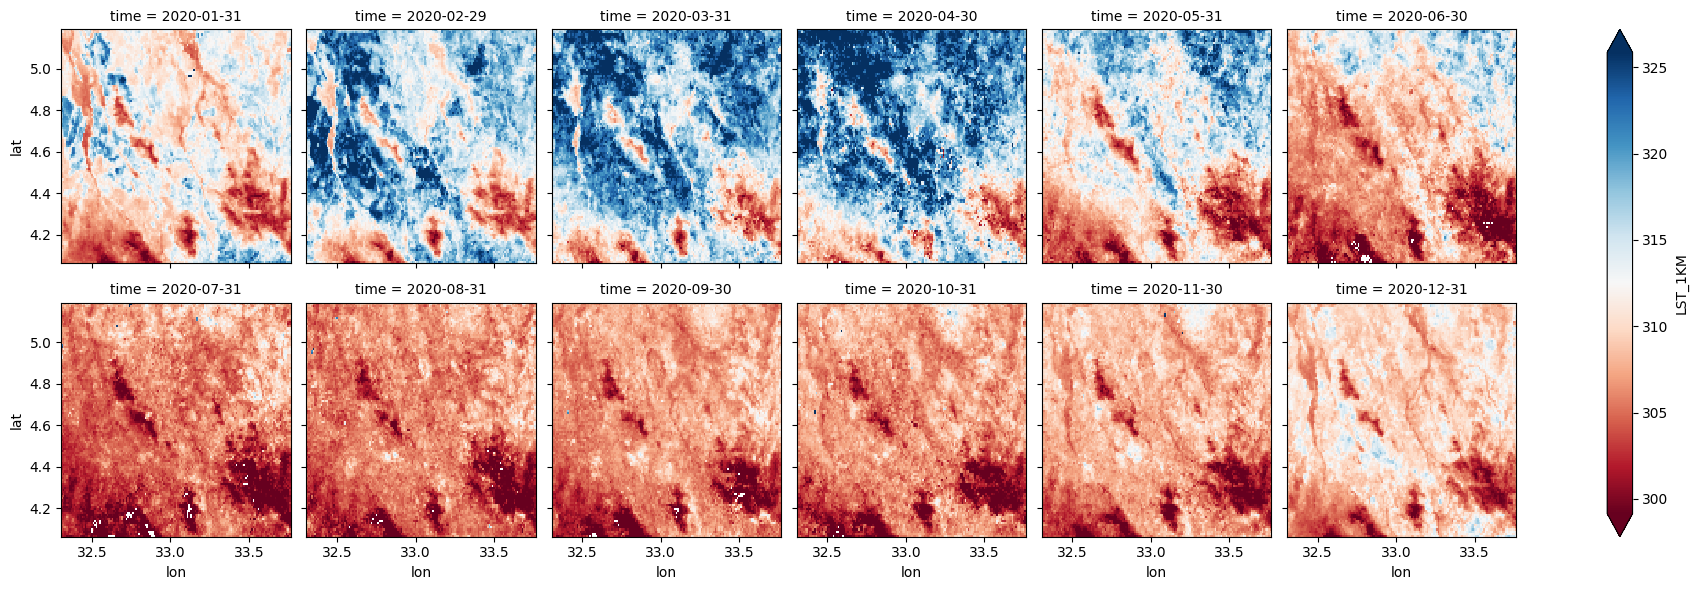

In [96]:
merge.LST_1KM.plot(
    x = "lon", y = "lat", col = "time", col_wrap = 6, cmap = "RdBu", robust = True
)

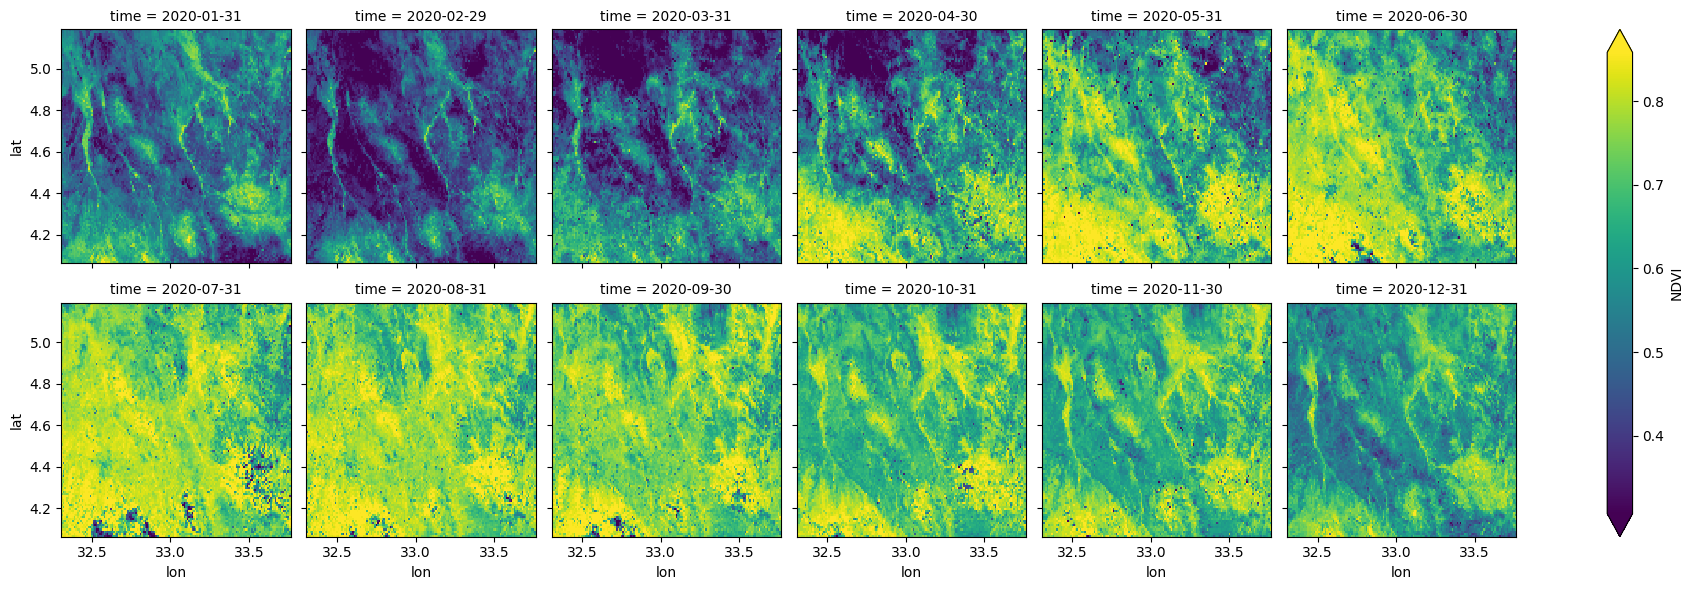

In [97]:
merge.NDVI.plot(
    x = "lon", y = "lat", col = "time", col_wrap = 6, cmap = 'viridis', robust = True
)